# TASK 1

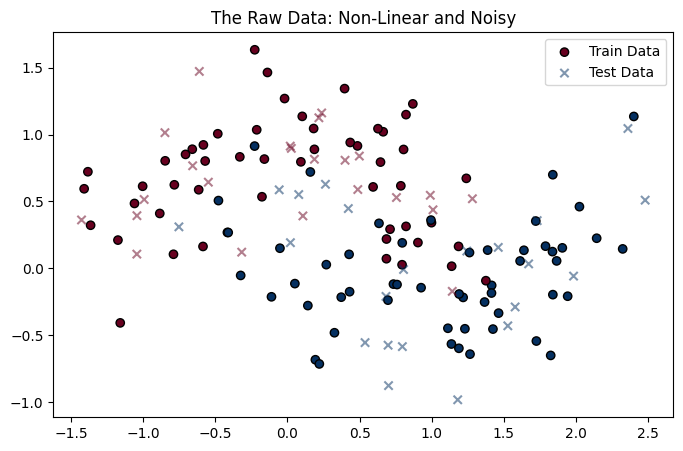

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Generate noisy data
X, y = make_moons(n_samples=150, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Plot the raw data
plt.figure(figsize=(8, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdBu', edgecolors='k', label= "Train Data")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdBu', marker='x', alpha= 0.5, label="Test Data")
plt.title("The Raw Data: Non-Linear and Noisy")
plt.legend()
plt.show()

## LOGISTIC REGRESSION BEFORE REGULARIZATION

In [2]:

poly = PolynomialFeatures(degree=10, include_bias=False)
scaler = StandardScaler()
X_train_t = scaler.fit_transform(poly.fit_transform(X_train))
X_test_t = scaler.transform(poly.transform(X_test))

clf = LogisticRegression(penalty=None, max_iter=1000, random_state=42)
clf.fit(X_train_t, y_train)
y_pred = clf.predict(X_test_t)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8666666666666667


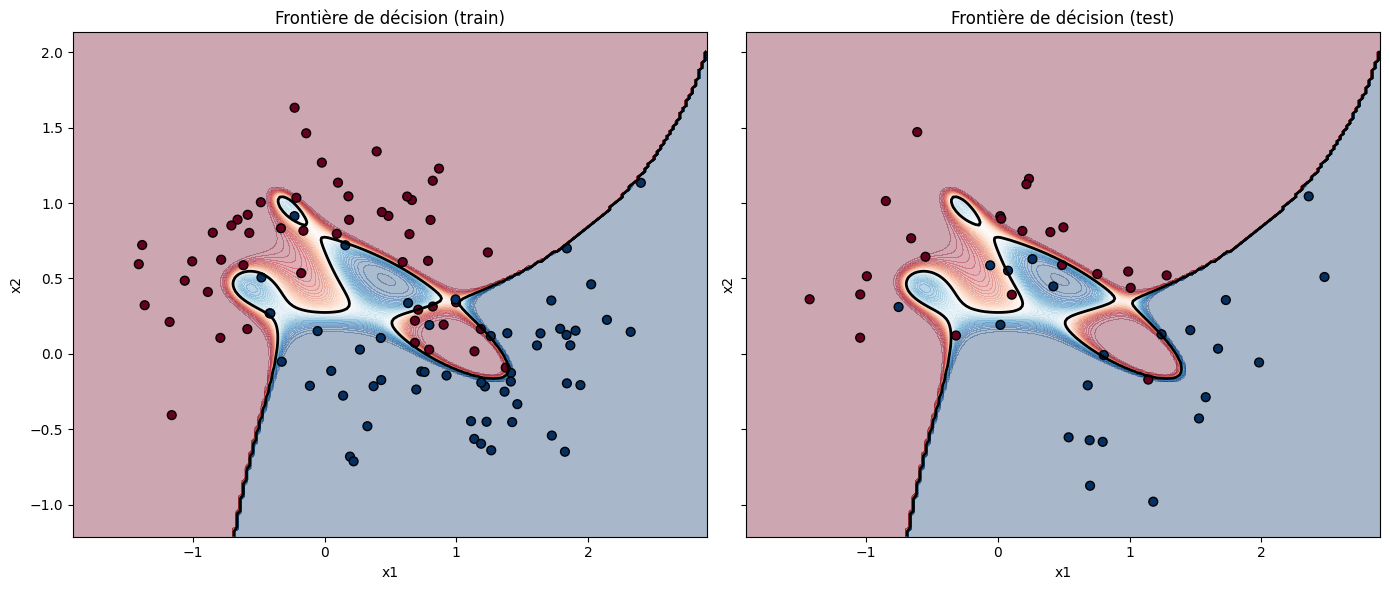

In [3]:
# Visualisation frontière : train et test côte à côte (même grille, poly puis scaler)

x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200),
)
grid = np.c_[xx.ravel(), yy.ravel()]

grid_t = scaler.transform(poly.transform(grid))
Z = clf.predict_proba(grid_t)[:, 1].reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, X_plot, y_plot, title in [
    (axes[0], X_train, y_train, "Frontière de décision (train)"),
    (axes[1], X_test, y_test, "Frontière de décision (test)"),
]:
    ax.contourf(xx, yy, Z, levels=50, cmap="RdBu", alpha=0.35)
    ax.contour(xx, yy, Z, levels=[0.5], colors="k", linewidths=2)
    ax.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, cmap="RdBu", edgecolors="k", s=40)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.tight_layout()
plt.show()

## LOGISTIC REGRESSION WITH L1

In [4]:

poly = PolynomialFeatures(degree=10, include_bias=False)
scaler = StandardScaler()
X_train_t = scaler.fit_transform(poly.fit_transform(X_train))
X_test_t = scaler.transform(poly.transform(X_test))

clf = LogisticRegression(penalty="l1",  solver="liblinear", max_iter=1000, random_state=42)
clf.fit(X_train_t, y_train)
y_pred = clf.predict(X_test_t)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8444444444444444


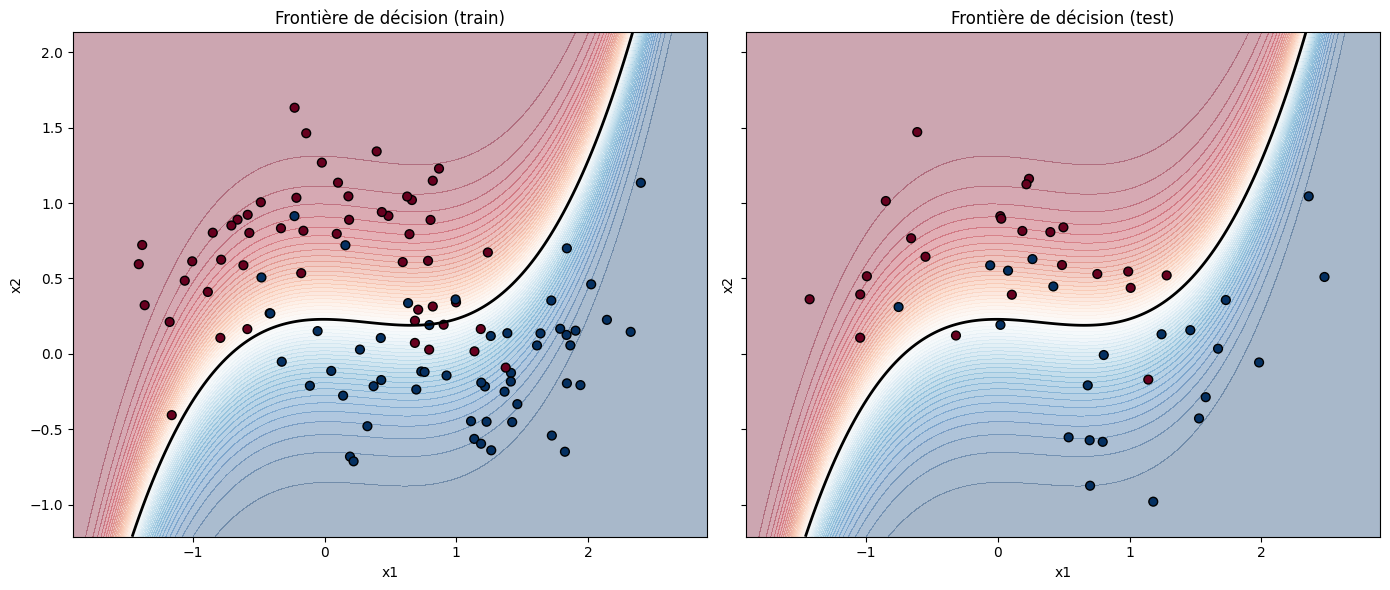

In [5]:
# Visualisation frontière : train et test côte à côte (même grille, poly puis scaler)

x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200),
)
grid = np.c_[xx.ravel(), yy.ravel()]

grid_t = scaler.transform(poly.transform(grid))
Z = clf.predict_proba(grid_t)[:, 1].reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, X_plot, y_plot, title in [
    (axes[0], X_train, y_train, "Frontière de décision (train)"),
    (axes[1], X_test, y_test, "Frontière de décision (test)"),
]:
    ax.contourf(xx, yy, Z, levels=50, cmap="RdBu", alpha=0.35)
    ax.contour(xx, yy, Z, levels=[0.5], colors="k", linewidths=2)
    ax.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, cmap="RdBu", edgecolors="k", s=40)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.tight_layout()
plt.show()

l2 neglige les coefficients et l1 kitseft lzero nishan

## LOGISTIC REGRESSION WITH L2

In [6]:

poly = PolynomialFeatures(degree=10, include_bias=False)
scaler = StandardScaler()
X_train_t = scaler.fit_transform(poly.fit_transform(X_train))
X_test_t = scaler.transform(poly.transform(X_test))

clf = LogisticRegression(penalty="l2", max_iter=1000, random_state=42)
clf.fit(X_train_t, y_train)
y_pred = clf.predict(X_test_t)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8444444444444444


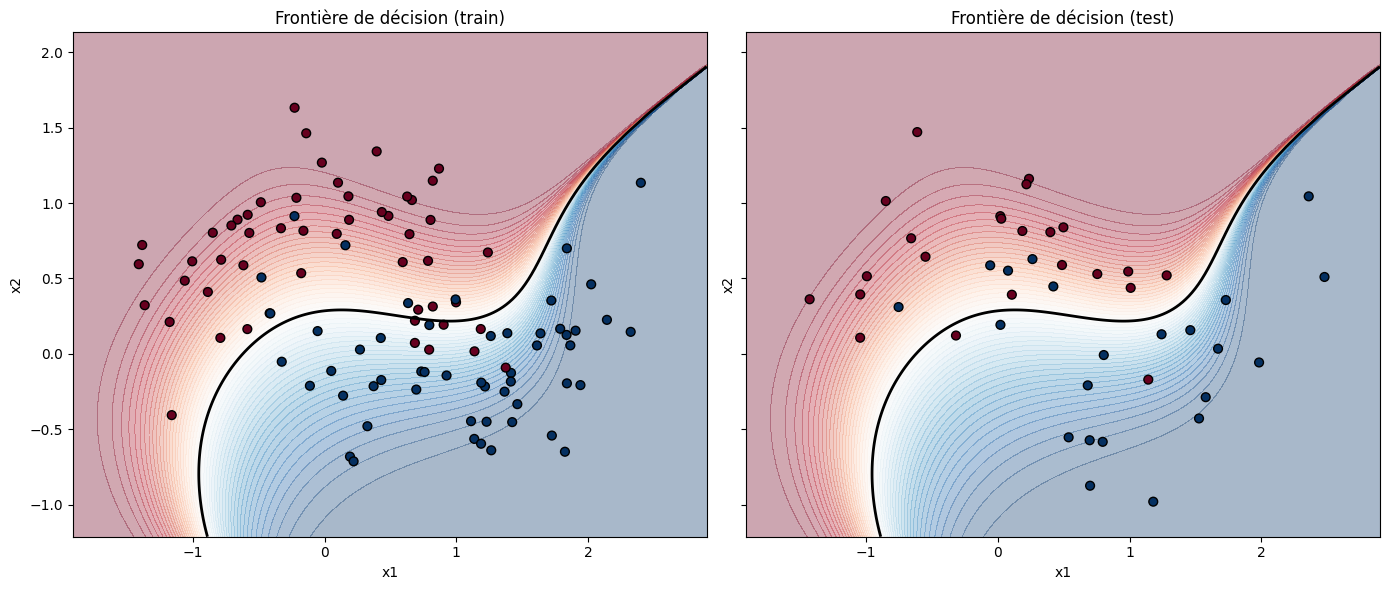

In [7]:
# Visualisation frontière : train et test côte à côte (même grille, poly puis scaler)

x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200),
)
grid = np.c_[xx.ravel(), yy.ravel()]

grid_t = scaler.transform(poly.transform(grid))
Z = clf.predict_proba(grid_t)[:, 1].reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, X_plot, y_plot, title in [
    (axes[0], X_train, y_train, "Frontière de décision (train)"),
    (axes[1], X_test, y_test, "Frontière de décision (test)"),
]:
    ax.contourf(xx, yy, Z, levels=50, cmap="RdBu", alpha=0.35)
    ax.contour(xx, yy, Z, levels=[0.5], colors="k", linewidths=2)
    ax.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, cmap="RdBu", edgecolors="k", s=40)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.tight_layout()
plt.show()

# TASK 2

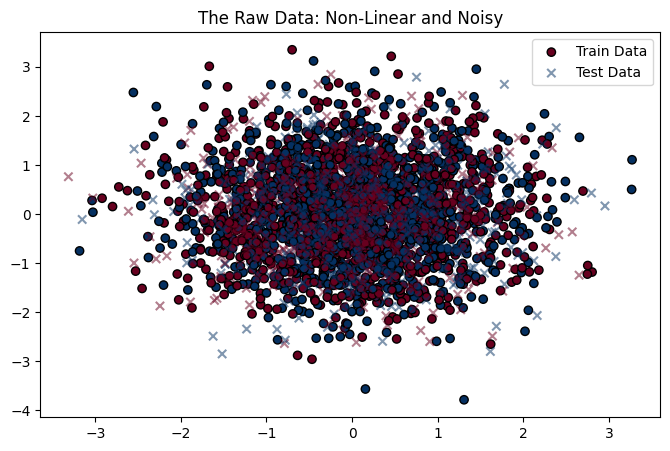

(3000, 50)


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Generate noisy data
X, y = make_classification(n_samples=3000, n_features=50, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Plot the raw data
plt.figure(figsize=(8, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdBu', edgecolors='k', label= "Train Data")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdBu', marker='x', alpha= 0.5, label="Test Data")
plt.title("The Raw Data: Non-Linear and Noisy")
plt.legend()
plt.show()
print(X.shape)

## 2 degrees with no regularization

In [9]:

poly = PolynomialFeatures(degree=2, include_bias=False)
scaler = StandardScaler()
X_train_t = scaler.fit_transform(poly.fit_transform(X_train))
X_test_t = scaler.transform(poly.transform(X_test))

clf = LogisticRegression(penalty=None, max_iter=1000, random_state=42)
clf.fit(X_train_t, y_train)
y_pred = clf.predict(X_test_t)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9166666666666666


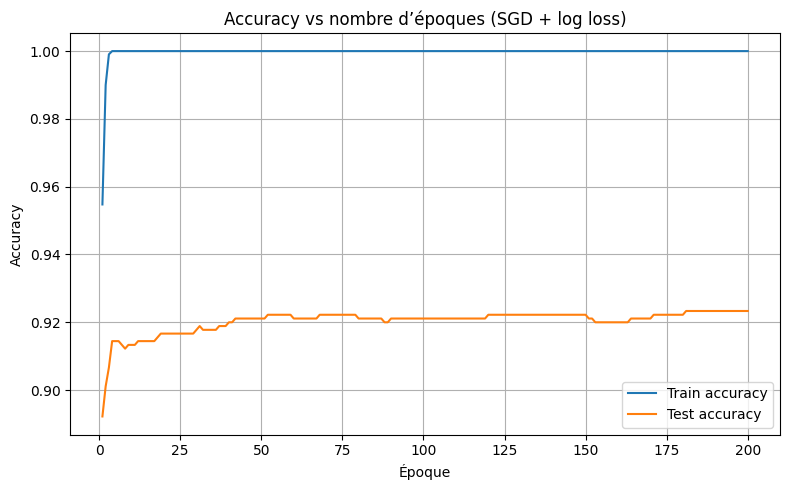

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

X_train_t = scaler.fit_transform(poly.fit_transform(X_train))
X_test_t = scaler.transform(poly.transform(X_test))

clf_sgd = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.01,
    random_state=42,
)

n_epochs = 200
train_acc, test_acc = [], []

for epoch in range(n_epochs):
    clf_sgd.partial_fit(X_train_t, y_train, classes=np.array([0, 1]))
    train_acc.append(accuracy_score(y_train, clf_sgd.predict(X_train_t)))
    test_acc.append(accuracy_score(y_test, clf_sgd.predict(X_test_t)))

epochs = np.arange(1, n_epochs + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Train accuracy")
plt.plot(epochs, test_acc, label="Test accuracy")
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.title("Accuracy vs nombre d’époques (SGD + log loss)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 2 degrees with L1

In [11]:

poly = PolynomialFeatures(degree=2, include_bias=False)
scaler = StandardScaler()
X_train_t = scaler.fit_transform(poly.fit_transform(X_train))
X_test_t = scaler.transform(poly.transform(X_test))

clf = LogisticRegression(penalty="l1",  solver="liblinear", max_iter=1000, random_state=42)
clf.fit(X_train_t, y_train)
y_pred = clf.predict(X_test_t)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9511111111111111


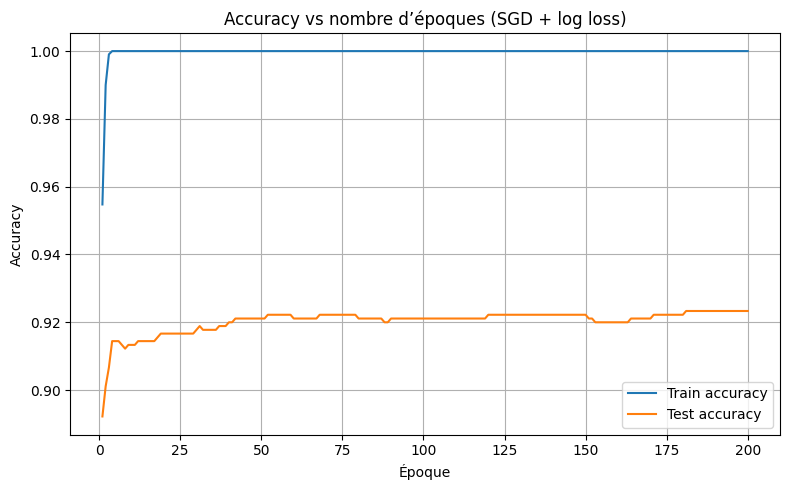

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

X_train_t = scaler.fit_transform(poly.fit_transform(X_train))
X_test_t = scaler.transform(poly.transform(X_test))

clf_sgd = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.01,
    random_state=42,
)

n_epochs = 200
train_acc, test_acc = [], []

for epoch in range(n_epochs):
    clf_sgd.partial_fit(X_train_t, y_train, classes=np.array([0, 1]))
    train_acc.append(accuracy_score(y_train, clf_sgd.predict(X_train_t)))
    test_acc.append(accuracy_score(y_test, clf_sgd.predict(X_test_t)))

epochs = np.arange(1, n_epochs + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Train accuracy")
plt.plot(epochs, test_acc, label="Test accuracy")
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.title("Accuracy vs nombre d’époques (SGD + log loss)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 2 degrees with L2

In [13]:

poly = PolynomialFeatures(degree=2, include_bias=False)
scaler = StandardScaler()
X_train_t = scaler.fit_transform(poly.fit_transform(X_train))
X_test_t = scaler.transform(poly.transform(X_test))

clf = LogisticRegression(penalty="l2", max_iter=1000, random_state=42)
clf.fit(X_train_t, y_train)
y_pred = clf.predict(X_test_t)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9266666666666666


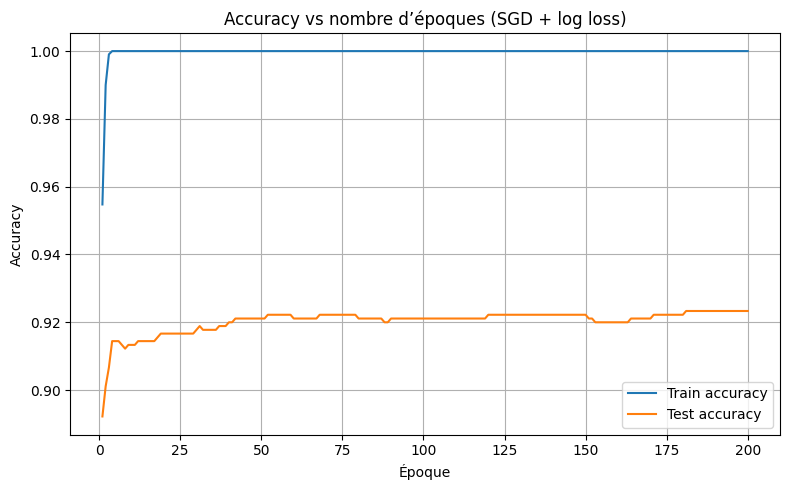

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

X_train_t = scaler.fit_transform(poly.fit_transform(X_train))
X_test_t = scaler.transform(poly.transform(X_test))

clf_sgd = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.01,
    random_state=42,
)

n_epochs = 200
train_acc, test_acc = [], []

for epoch in range(n_epochs):
    clf_sgd.partial_fit(X_train_t, y_train, classes=np.array([0, 1]))
    train_acc.append(accuracy_score(y_train, clf_sgd.predict(X_train_t)))
    test_acc.append(accuracy_score(y_test, clf_sgd.predict(X_test_t)))

epochs = np.arange(1, n_epochs + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Train accuracy")
plt.plot(epochs, test_acc, label="Test accuracy")
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.title("Accuracy vs nombre d’époques (SGD + log loss)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3 degrees with no regularization

In [15]:

poly = PolynomialFeatures(degree=3, include_bias=False)
scaler = StandardScaler()
X_train_t = scaler.fit_transform(poly.fit_transform(X_train))
X_test_t = scaler.transform(poly.transform(X_test))

clf = LogisticRegression(penalty=None, max_iter=1000, random_state=42)
clf.fit(X_train_t, y_train)
y_pred = clf.predict(X_test_t)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9488888888888889


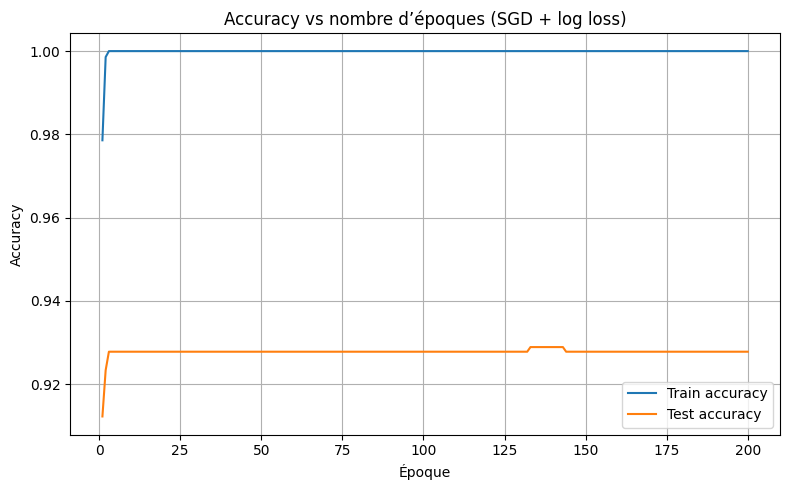

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

X_train_t = scaler.fit_transform(poly.fit_transform(X_train))
X_test_t = scaler.transform(poly.transform(X_test))

clf_sgd = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.01,
    random_state=42,
)

n_epochs = 200
train_acc, test_acc = [], []

for epoch in range(n_epochs):
    clf_sgd.partial_fit(X_train_t, y_train, classes=np.array([0, 1]))
    train_acc.append(accuracy_score(y_train, clf_sgd.predict(X_train_t)))
    test_acc.append(accuracy_score(y_test, clf_sgd.predict(X_test_t)))

epochs = np.arange(1, n_epochs + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Train accuracy")
plt.plot(epochs, test_acc, label="Test accuracy")
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.title("Accuracy vs nombre d’époques (SGD + log loss)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3 degrees with L1

In [17]:

poly = PolynomialFeatures(degree=3, include_bias=False)
scaler = StandardScaler()
X_train_t = scaler.fit_transform(poly.fit_transform(X_train))
X_test_t = scaler.transform(poly.transform(X_test))

clf = LogisticRegression(penalty="l1",  solver="liblinear", max_iter=1000, random_state=42)
clf.fit(X_train_t, y_train)
y_pred = clf.predict(X_test_t)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9633333333333334


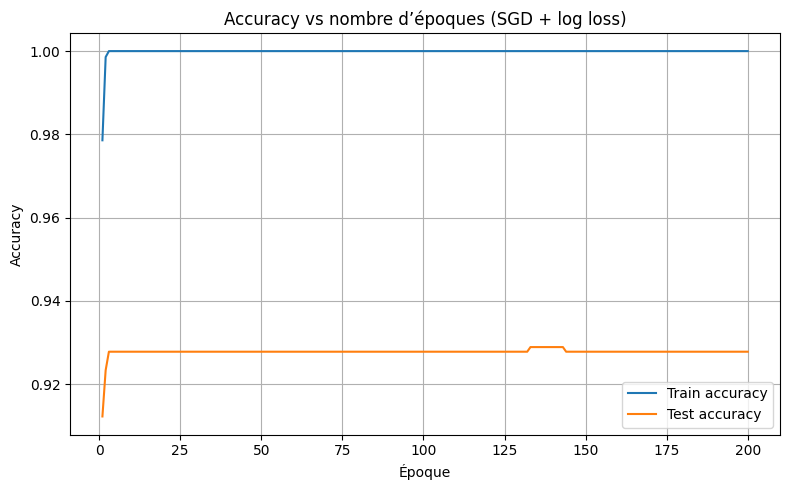

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

X_train_t = scaler.fit_transform(poly.fit_transform(X_train))
X_test_t = scaler.transform(poly.transform(X_test))

clf_sgd = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.01,
    random_state=42,
)

n_epochs = 200
train_acc, test_acc = [], []

for epoch in range(n_epochs):
    clf_sgd.partial_fit(X_train_t, y_train, classes=np.array([0, 1]))
    train_acc.append(accuracy_score(y_train, clf_sgd.predict(X_train_t)))
    test_acc.append(accuracy_score(y_test, clf_sgd.predict(X_test_t)))

epochs = np.arange(1, n_epochs + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Train accuracy")
plt.plot(epochs, test_acc, label="Test accuracy")
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.title("Accuracy vs nombre d’époques (SGD + log loss)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3 degrees with L2

In [19]:

poly = PolynomialFeatures(degree=3, include_bias=False)
scaler = StandardScaler()
X_train_t = scaler.fit_transform(poly.fit_transform(X_train))
X_test_t = scaler.transform(poly.transform(X_test))

clf = LogisticRegression(penalty="l2", max_iter=1000, random_state=42)
clf.fit(X_train_t, y_train)
y_pred = clf.predict(X_test_t)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9511111111111111


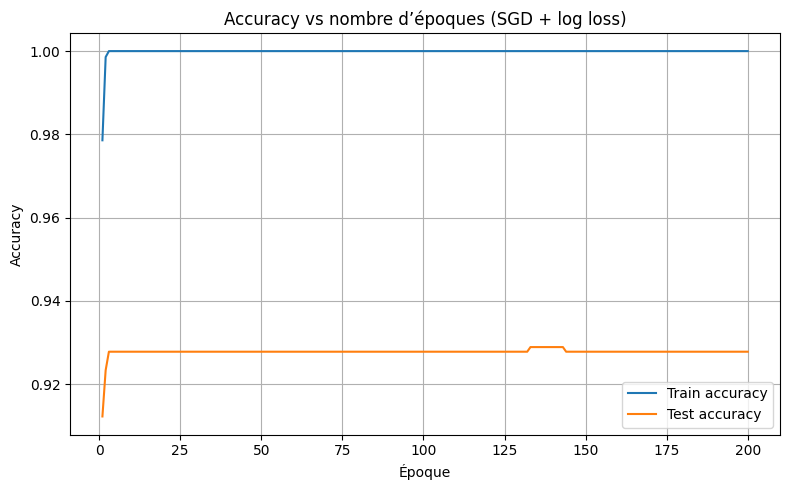

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

X_train_t = scaler.fit_transform(poly.fit_transform(X_train))
X_test_t = scaler.transform(poly.transform(X_test))

clf_sgd = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.01,
    random_state=42,
)

n_epochs = 200
train_acc, test_acc = [], []

for epoch in range(n_epochs):
    clf_sgd.partial_fit(X_train_t, y_train, classes=np.array([0, 1]))
    train_acc.append(accuracy_score(y_train, clf_sgd.predict(X_train_t)))
    test_acc.append(accuracy_score(y_test, clf_sgd.predict(X_test_t)))

epochs = np.arange(1, n_epochs + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Train accuracy")
plt.plot(epochs, test_acc, label="Test accuracy")
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.title("Accuracy vs nombre d’époques (SGD + log loss)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()